In [3]:
import pandas as pd

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

In [4]:
df = movies.merge(credits, on="title")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
import ast

def get_first_actor_info(cast_str):
    cast_list = ast.literal_eval(cast_str)
    if len(cast_list) > 0:
        return pd.Series([cast_list[0]['name'], cast_list[0]['id']])
    return pd.Series([None, None])

df[['lead_actor', 'lead_actor_id']] = df['cast'].apply(get_first_actor_info)
df[['title', 'lead_actor', 'lead_actor_id']].head()

,title,lead_actor,lead_actor_id
0,Avatar,Sam Worthington,65731.0
1,Pirates of the Caribbean: At World's End,Johnny Depp,85.0
2,Spectre,Daniel Craig,8784.0
3,The Dark Knight Rises,Christian Bale,3894.0
4,John Carter,Taylor Kitsch,60900.0


In [16]:
import requests

API_KEY = "830488df71da7c482deba050fe0973d7"

def get_actor_origin(actor_id):
    url = f"https://api.themoviedb.org/3/person/{actor_id}?api_key={API_KEY}"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        return data.get("place_of_birth")
    else:
        return None

In [17]:
get_actor_origin(df['lead_actor_id'].iloc[0])

'Godalming, Surrey, England, UK'

In [18]:
western_keywords = [
    # USA & similar
    "USA", "United States", "America",
    
    # Canada & Australia
    "Canada", "Australia", "New Zealand",
    
    # UK + Europe (major)
    "UK", "England", "Scotland", "Ireland",
    "France", "Germany", "Italy", "Spain", "Portugal",
    "Netherlands", "Belgium", "Switzerland", "Austria",
    "Sweden", "Norway", "Denmark", "Finland",
    "Poland", "Czech", "Slovakia", "Hungary",
    "Greece", "Romania", "Bulgaria",
    
    # Russia
    "Russia", "Russian"
]

In [19]:
def classify_origin(place):
    if not isinstance(place, str):
        return None
    
    if "Turkey" in place:
        return "Non-Western"
    
    for country in western_keywords:
        if country in place:
            return "Western"
    
    return "Non-Western"

In [20]:
sample = df[['lead_actor', 'lead_actor_id']].head(5).copy()
sample['origin_raw'] = sample['lead_actor_id'].apply(get_actor_origin)
sample

,lead_actor,lead_actor_id,origin_raw
0,Sam Worthington,65731.0,"Godalming, Surrey, England, UK"
1,Johnny Depp,85.0,"Owensboro, Kentucky, USA"
2,Daniel Craig,8784.0,"Chester, Cheshire, England, UK"
3,Christian Bale,3894.0,"Haverfordwest, Pembrokeshire, Wales, UK"
4,Taylor Kitsch,60900.0,"Kelowna, British Columbia, Canada"


In [21]:
sample['origin'] = sample['origin_raw'].apply(classify_origin)
sample

,lead_actor,lead_actor_id,origin_raw,origin
0,Sam Worthington,65731.0,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,85.0,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,8784.0,"Chester, Cheshire, England, UK",Western
3,Christian Bale,3894.0,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,60900.0,"Kelowna, British Columbia, Canada",Western


In [22]:
unique_actors = df[['lead_actor', 'lead_actor_id']].drop_duplicates()

In [23]:
unique_actors.head()
len(unique_actors)

2096

In [28]:
unique_actors['origin_raw'] = unique_actors['lead_actor_id'].apply(get_actor_origin)

In [45]:
unique_actors.head()

,lead_actor,lead_actor_id,origin_raw,origin
0,Sam Worthington,65731.0,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,85.0,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,8784.0,"Chester, Cheshire, England, UK",Western
3,Christian Bale,3894.0,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,60900.0,"Kelowna, British Columbia, Canada",Western


In [46]:
unique_actors['origin'] = unique_actors['origin_raw'].apply(classify_origin)

In [47]:
unique_actors['origin'].value_counts(dropna=False)

origin
Western        1744
Non-Western     201
NaN             151
Name: count, dtype: int64

In [51]:
df = df.merge(unique_actors[['lead_actor_id', 'origin']], 
              on='lead_actor_id', 
              how='left')

In [52]:
df['origin'].value_counts(dropna=False)

origin
Western        4291
Non-Western     325
Name: count, dtype: int64

In [53]:
df = df.dropna(subset=['origin'])

In [ ]:
#have the data set now compare budget rating blah blah blah

In [54]:
df.groupby('origin')['budget'].mean()

origin
Non-Western    1.801205e+07
Western        3.105039e+07
Name: budget, dtype: float64

In [55]:
df.groupby('origin')['vote_average'].mean()

origin
Non-Western    6.286462
Western        6.136681
Name: vote_average, dtype: float64

In [56]:
df.groupby('origin')['popularity'].mean()

origin
Non-Western    15.264447
Western        22.819054
Name: popularity, dtype: float64

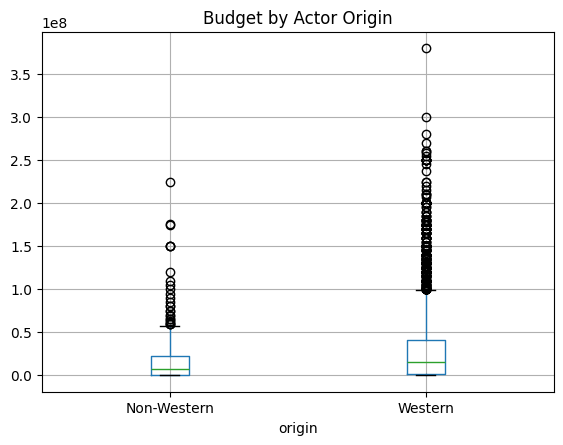

In [57]:
import matplotlib.pyplot as plt

df.boxplot(column='budget', by='origin')
plt.title("Budget by Actor Origin")
plt.suptitle("")
plt.show()

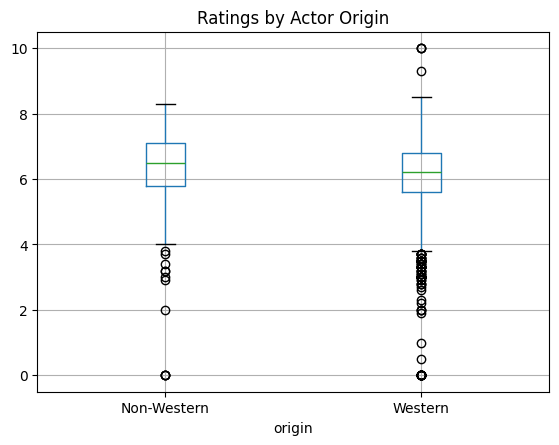

In [58]:
df.boxplot(column='vote_average', by='origin')
plt.title("Ratings by Actor Origin")
plt.suptitle("")
plt.show()

In [ ]:
#the data is done EDA is done now we do hypothesis testing

In [59]:
from scipy.stats import ttest_ind

western = df[df['origin'] == 'Western']['budget']
non_western = df[df['origin'] == 'Non-Western']['budget']

ttest_ind(western, non_western, equal_var=False)

TtestResult(statistic=np.float64(7.236955135876408), pvalue=np.float64(2.1833028364548826e-12), df=np.float64(422.0244856658062))

In [60]:
#There is a statistically significant difference in movie budgets between Western and Non-Western lead actors. Reject Hypothseis

In [61]:
ttest_ind(
    df[df['origin']=='Western']['vote_average'],
    df[df['origin']=='Non-Western']['vote_average'],
    equal_var=False
)

TtestResult(statistic=np.float64(-2.1418011472095237), pvalue=np.float64(0.03287850230290326), df=np.float64(360.8597520672518))

In [ ]:
#Non western movies have higher ratings

In [62]:
ttest_ind(
    df[df['origin']=='Western']['popularity'],
    df[df['origin']=='Non-Western']['popularity'],
    equal_var=False
)

TtestResult(statistic=np.float64(6.430034007307237), pvalue=np.float64(3.0696799571978314e-10), df=np.float64(482.9653760540409))

In [ ]:
#Western movies are more popular

In [ ]:
#use linear progression method for ML, since the data is mostly numerical

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [64]:
ml_df = df[['budget', 'popularity', 'origin', 'vote_average']].copy()

ml_df['origin_binary'] = ml_df['origin'].map({
    'Western': 1,
    'Non-Western': 0
})
#make origin into numbers

ml_df = ml_df.dropna()
ml_df.head()

,budget,popularity,origin,vote_average,origin_binary
0,237000000,150.437577,Western,7.2,1
1,300000000,139.082615,Western,6.9,1
2,245000000,107.376788,Western,6.3,1
3,250000000,112.312950,Western,7.6,1
4,260000000,43.926995,Western,6.1,1


In [65]:
X = ml_df[['budget', 'popularity', 'origin_binary']]
y = ml_df['vote_average']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
y_pred = model.predict(X_test)

In [69]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 1.1830858392157257
R²: 0.0286618518992664


In [70]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,budget,-2.843472e-09
1,popularity,1.267209e-02
2,origin_binary,-1.850285e-01


In [ ]:
#results are not as good as expected try more stuff-try more variables with decision tree

In [71]:
import numpy as np

ml_df2 = ml_df.copy()

ml_df2['log_budget'] = np.log1p(ml_df2['budget'])

ml_df2 = ml_df2.dropna()

In [73]:
import numpy as np

ml_df2 = df[['budget', 'popularity', 'origin', 'vote_average', 'vote_count', 'runtime']].copy()

ml_df2['origin_binary'] = ml_df2['origin'].map({
    'Western': 1,
    'Non-Western': 0
})

ml_df2['log_budget'] = np.log1p(ml_df2['budget'])

ml_df2 = ml_df2.dropna()
ml_df2.head()

,budget,popularity,origin,vote_average,vote_count,runtime,origin_binary,log_budget
0,237000000,150.437577,Western,7.2,11800,162.0,1,19.283571
1,300000000,139.082615,Western,6.9,4500,169.0,1,19.519293
2,245000000,107.376788,Western,6.3,4466,148.0,1,19.316769
3,250000000,112.312950,Western,7.6,9106,165.0,1,19.336971
4,260000000,43.926995,Western,6.1,2124,132.0,1,19.376192


In [74]:
X2 = ml_df2[['log_budget', 'popularity', 'origin_binary', 'vote_count', 'runtime']]
y2 = ml_df2['vote_average']

In [75]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [76]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_train2, y_train2)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [77]:
y_pred_tree = tree.predict(X_test2)

In [78]:
from sklearn.metrics import mean_squared_error, r2_score

mse_tree = mean_squared_error(y_test2, y_pred_tree)
r2_tree = r2_score(y_test2, y_pred_tree)

print("Decision Tree MSE:", mse_tree)
print("Decision Tree R²:", r2_tree)

Decision Tree MSE: 0.6179237836762831
Decision Tree R²: 0.44537992883535094


In [ ]:
#using non-linear mothod worked better im so happy. 3% -> 44% yey!